# 02 - Modelo ML Clássico: Random Forest
O Random Forest é um algoritmo de aprendizado de máquina baseado em múltiplas árvores de decisão. Foi escolhido por sua robustez, boa performance em dados textuais e facilidade de interpretação dos resultados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Bibliotecas carregadas!")

Bibliotecas carregadas!


In [2]:
# Carrega o dataset já limpo pelo notebook anterior
df = pd.read_csv('../data/phishing_email_limpo.csv')

print(f"Dataset carregado: {df.shape}")
df.head()

Dataset carregado: (82403, 2)


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [3]:
# TF-IDF transforma o texto em números que o modelo consegue entender
# max_features=5000 limita para as 5000 palavras mais importantes do dataset
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# Separa o texto (X) e o label (y)
X = tfidf.fit_transform(df['text_combined'])
y = df['label']

print(f"Matriz TF-IDF gerada: {X.shape}")
print(f"Cada e-mail virou um vetor de {X.shape[1]} números")

Matriz TF-IDF gerada: (82403, 5000)
Cada e-mail virou um vetor de 5000 números


In [4]:
# Divide o dataset: 80% para treinar e 20% para testar
# random_state=42 garante que a divisão seja sempre a mesma
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treino: {X_train.shape[0]} e-mails")
print(f"Teste:  {X_test.shape[0]} e-mails")

Treino: 65922 e-mails
Teste:  16481 e-mails


In [5]:
# Cria o modelo com 100 árvores de decisão
# n_jobs=-1 usa todos os núcleos do processador para treinar mais rápido
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Treina o modelo
print("Treinando o modelo... aguarde!")
rf.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Treinando o modelo... aguarde!
Modelo treinado com sucesso!


In [6]:
# Faz as previsões no conjunto de teste
y_pred = rf.predict(X_test)

# Exibe a acurácia geral
print(f"Acurácia: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

# Exibe o relatório completo com precisão, recall e f1-score
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Legítimo', 'Phishing']))

Acurácia: 98.77%

Relatório de Classificação:
              precision    recall  f1-score   support

    Legítimo       0.99      0.99      0.99      8027
    Phishing       0.99      0.99      0.99      8454

    accuracy                           0.99     16481
   macro avg       0.99      0.99      0.99     16481
weighted avg       0.99      0.99      0.99     16481



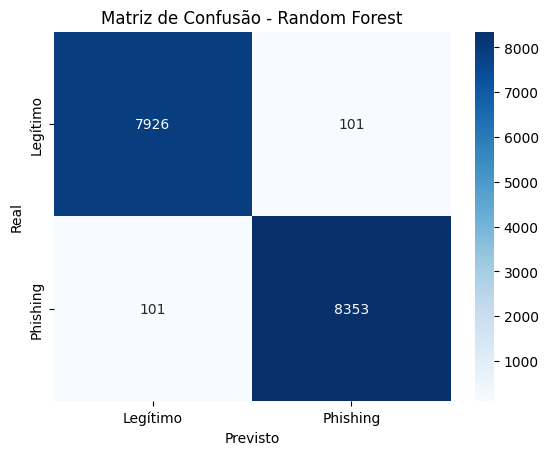

In [7]:
# Gera a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Plota a matriz de forma visual
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítimo', 'Phishing'],
            yticklabels=['Legítimo', 'Phishing'])

plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

In [8]:
import joblib

# Salva o modelo e o vetorizador para usar no Streamlit depois
joblib.dump(rf, '../models/random_forest.pkl')
joblib.dump(tfidf, '../models/tfidf_vectorizer.pkl')

print("Modelo e vetorizador salvos!")

Modelo e vetorizador salvos!
